<a href="https://colab.research.google.com/github/jigyasaG01/cattle_breed/blob/main/predictionf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!unzip "/Users/urvashishekhawat/cattle_breed/rajasthan_cattle_dataset_2.zip"

Archive:  /Users/urvashishekhawat/cattle_breed/rajasthan_cattle_dataset_2.zip
   creating: rajasthan_cattle_dataset 2/
  inflating: __MACOSX/._rajasthan_cattle_dataset 2  
  inflating: rajasthan_cattle_dataset 2/.DS_Store  
  inflating: __MACOSX/rajasthan_cattle_dataset 2/._.DS_Store  
   creating: rajasthan_cattle_dataset 2/test/
  inflating: __MACOSX/rajasthan_cattle_dataset 2/._test  
   creating: rajasthan_cattle_dataset 2/train/
  inflating: __MACOSX/rajasthan_cattle_dataset 2/._train  
   creating: rajasthan_cattle_dataset 2/test/Mehsana/
  inflating: __MACOSX/rajasthan_cattle_dataset 2/test/._Mehsana  
   creating: rajasthan_cattle_dataset 2/test/Kankrej/
  inflating: __MACOSX/rajasthan_cattle_dataset 2/test/._Kankrej  
   creating: rajasthan_cattle_dataset 2/test/Sahiwal/
  inflating: __MACOSX/rajasthan_cattle_dataset 2/test/._Sahiwal  
  inflating: rajasthan_cattle_dataset 2/test/.DS_Store  
  inflating: __MACOSX/rajasthan_cattle_dataset 2/test/._.DS_Store  
   creating: rajas

In [8]:
!ls rajasthan_cattle_dataset_2

test  train


In [10]:
!ls /Users/urvashishekhawat/cattle_breed/rajasthan_cattle_dataset_2/train

Bhadawari  Kankrej    Murrah     Rathi      Sahiwal    gir
Hariana    Mehsana    Nagori     Red_Sindhi Surti      tharparkar


In [11]:
!ls /Users/urvashishekhawat/cattle_breed/rajasthan_cattle_dataset_2/test

Bhadawari  Kankrej    Murrah     Rathi      Sahiwal    gir
Hariana    Mehsana    Nagori     Red_Sindhi Surti      tharparkar


In [12]:
import os, shutil, random

SRC = "/Users/urvashishekhawat/cattle_breed/rajasthan_cattle_dataset_2/train"
DEST = "data"
VAL_RATIO = 0.2

def is_image(fname):
    return fname.lower().endswith(('.jpg', '.jpeg', '.png'))

# optional: clean old split
if os.path.exists(DEST):
    shutil.rmtree(DEST)

for split in ["train", "val"]:
    os.makedirs(f"{DEST}/{split}", exist_ok=True)

for breed in os.listdir(SRC):
    breed_path = os.path.join(SRC, breed)
    if not os.path.isdir(breed_path):
        continue   # 👈 skips .DS_Store and files

    os.makedirs(f"{DEST}/train/{breed}", exist_ok=True)
    os.makedirs(f"{DEST}/val/{breed}", exist_ok=True)

    images = [img for img in os.listdir(breed_path) if is_image(img)]
    random.shuffle(images)

    val_count = int(len(images) * VAL_RATIO)

    for img in images[val_count:]:
        shutil.copy(
            os.path.join(breed_path, img),
            f"{DEST}/train/{breed}/{img}"
        )

    for img in images[:val_count]:
        shutil.copy(
            os.path.join(breed_path, img),
            f"{DEST}/val/{breed}/{img}"
        )


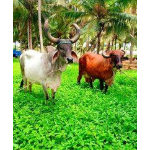

In [13]:
from PIL import Image
import random, os

breed = random.choice(os.listdir("data/train"))
img = random.choice(os.listdir(f"data/train/{breed}"))
Image.open(f"data/train/{breed}/{img}")


In [14]:
import torch
import torchvision
from torchvision import datasets, transforms, models
from torch import nn, optim
from torch.utils.data import DataLoader


In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

In [16]:
train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [17]:
train_ds = datasets.ImageFolder("data/train", transform=train_tfms)
val_ds   = datasets.ImageFolder("data/val", transform=val_tfms)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False)

class_names = train_ds.classes
num_classes = len(class_names)

print(class_names)
print("Number of classes:", num_classes)


['Bhadawari', 'Hariana', 'Kankrej', 'Mehsana', 'Murrah', 'Nagori', 'Rathi', 'Red_Sindhi', 'Sahiwal', 'Surti', 'gir', 'tharparkar']
Number of classes: 12


In [18]:
model = models.resnet18(pretrained=True)

# Freeze backbone
for param in model.parameters():
    param.requires_grad = False

# Replace classifier
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)


/Users/urvashishekhawat/Library/Python/3.9/lib/python/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/urvashishekhawat/Library/Python/3.9/lib/python/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/urvashishekhawat/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100.0%


In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)


In [20]:
epochs = 20

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Validation
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    val_acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss:.2f} | Val Acc: {val_acc:.2f}%")


Epoch 1/20 | Loss: 52.10 | Val Acc: 46.24%
Epoch 2/20 | Loss: 40.62 | Val Acc: 49.13%
Epoch 3/20 | Loss: 35.09 | Val Acc: 57.23%
Epoch 4/20 | Loss: 31.27 | Val Acc: 55.49%
Epoch 5/20 | Loss: 28.51 | Val Acc: 61.27%
Epoch 6/20 | Loss: 26.49 | Val Acc: 68.21%
Epoch 7/20 | Loss: 25.40 | Val Acc: 68.21%
Epoch 8/20 | Loss: 24.24 | Val Acc: 67.63%
Epoch 9/20 | Loss: 23.00 | Val Acc: 64.74%
Epoch 10/20 | Loss: 22.26 | Val Acc: 65.90%
Epoch 11/20 | Loss: 20.65 | Val Acc: 71.10%
Epoch 12/20 | Loss: 20.26 | Val Acc: 63.01%
Epoch 13/20 | Loss: 20.55 | Val Acc: 64.16%
Epoch 14/20 | Loss: 19.79 | Val Acc: 69.36%
Epoch 15/20 | Loss: 18.88 | Val Acc: 69.36%
Epoch 16/20 | Loss: 17.98 | Val Acc: 72.83%
Epoch 17/20 | Loss: 17.75 | Val Acc: 69.36%
Epoch 18/20 | Loss: 17.81 | Val Acc: 72.25%
Epoch 19/20 | Loss: 17.90 | Val Acc: 69.94%
Epoch 20/20 | Loss: 17.63 | Val Acc: 68.79%


In [21]:
torch.save(model.state_dict(), "rajasthan_cattle_modell.pth")


In [22]:
test_ds = datasets.ImageFolder("/Users/urvashishekhawat/cattle_breed/rajasthan_cattle_dataset_2/test", transform=val_tfms)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

model.eval()
correct, total = 0, 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

test_acc = 100 * correct / total
print(f"Test Accuracy: {test_acc:.2f}%")


Test Accuracy: 76.83%


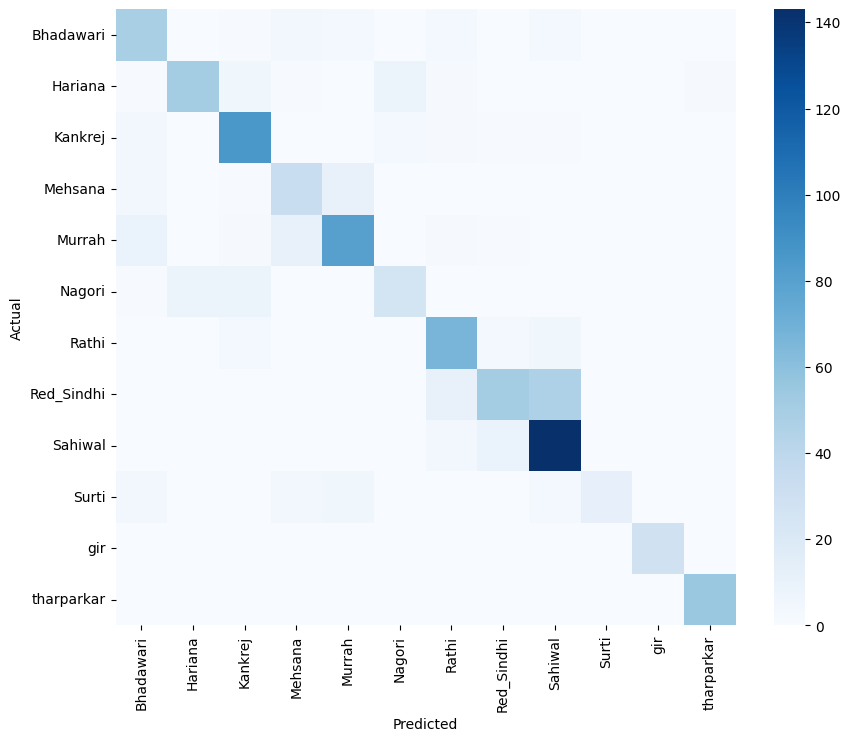

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, xticklabels=class_names, yticklabels=class_names,
            annot=False, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [27]:
from PIL import Image
import torch.nn.functional as F

def predict_image(img_path):
    img = Image.open(img_path).convert("RGB")
    img = val_tfms(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(img)
        probs = F.softmax(output, dim=1)
        conf, pred = torch.max(probs, 1)

    return class_names[pred.item()], conf.item()

breed, confidence = predict_image("/Users/urvashishekhawat/cattle_breed/gir.jpg")
print(f"Prediction: {breed} ({confidence*100:.2f}%)")


Prediction: Red_Sindhi (75.47%)
